# 🔁 Énigmes & Merveilles de Douglas Hofstadter

*Un notebook démo pour matheux, dans l'esprit de Douglas Hofstadter — cogniticien, informaticien et
essayiste, auteur de *Gödel, Escher, Bach: an Eternal Golden Braid* (Prix Pulitzer 1980), de
*Metamagical Themas*, de *I Am a Strange Loop*, et fondateur (avec Melanie Mitchell) du projet Copycat
sur le raisonnement par analogie.*

Ce notebook regroupe **8 énigmes / explorations** directement issues (ou inspirées) de ses livres, dans
la continuité de la démo JupyterLab entamée avec Gardner, Pickover, Stewart, Delahaye, du Sautoy et
Rucker — même recette : calcul, texte, visualisation et interactivité réunis dans un seul document.

**Sommaire**

1. [La suite G de Hofstadter](#1) — auto-référence numérique
2. [La suite Q de Hofstadter](#2) — chaos apparent
3. [Le système MIU et le puzzle MU](#3) — invariants et indécidabilité
4. [Le cube de Necker](#4) — figures ambiguës et impossibles
5. [Le dilemme du prisonnier et la super-rationalité](#5)
6. [Les canons crabes](#6) — palindromes musicaux à la Bach
7. [Boucles étranges : le quine](#7) — un programme qui s'imprime lui-même
8. [Copycat : le raisonnement par analogie](#8)
9. [Bac à sable interactif](#9)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. La suite G de Hofstadter <a id="1"></a>

Dès les premières pages de *Gödel, Escher, Bach* (1979), Hofstadter s'amuse avec des suites qui se
définissent en s'appelant elles-mêmes. La plus douce d'entre elles : $G(0)=0$, puis
$G(n) = n - G(G(n-1))$. Malgré l'auto-référence à double niveau, la suite se comporte étonnamment bien —
son taux de croissance $G(n)/n$ converge vers $1/\varphi \approx 0{,}618$, l'inverse du nombre d'or.

Premiers termes de G : [0, 1, 1, 2, 3, 3, 4, 4, 5, 6, 6, 7, 8, 8, 9, 9, 10, 11, 11, 12]
G(n)/n semble converger vers φ-1 ≈ 0.6180 (nombre d'or) : G(60)/60 = 0.6167


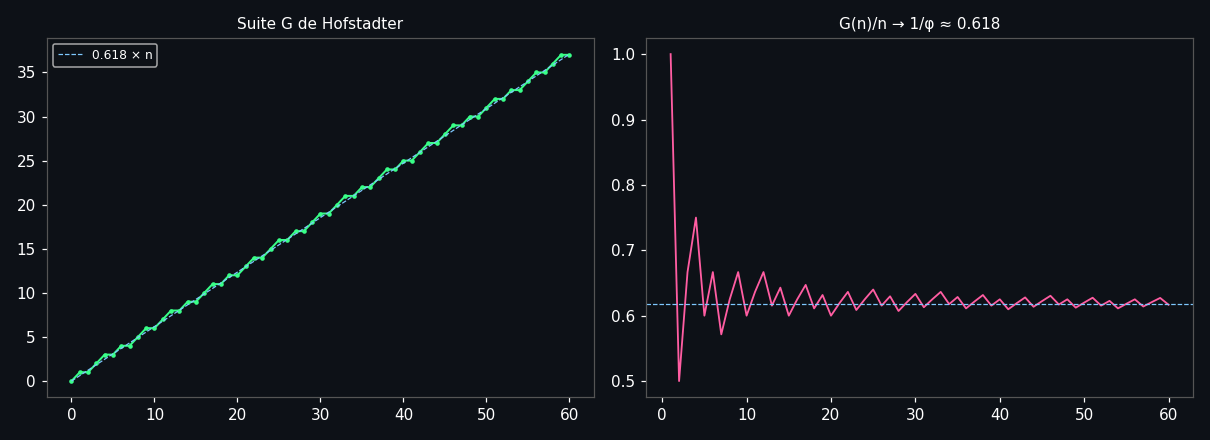

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# La suite G de Hofstadter (Gödel, Escher, Bach, 1979) : une suite définie par
# récurrence sur elle-même, l'archétype même de l'auto-référence numérique.
# G(0) = 0, et G(n) = n - G(G(n-1)) pour n >= 1.
def hofstadter_G(n_max):
    G = [0]
    for n in range(1, n_max+1):
        G.append(n - G[G[n-1]])
    return G

N = 60
G = hofstadter_G(N)
print("Premiers termes de G :", G[:20])
ratios = [G[n]/n for n in range(1, N+1)]
print(f"G(n)/n semble converger vers φ-1 ≈ 0.6180 (nombre d'or) : G({N})/{N} = {ratios[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor="#0d1117")
for ax in axes: ax.set_facecolor("#0d1117")
axes[0].plot(range(N+1), G, color="#39ff88", lw=1.3, marker="o", markersize=2)
axes[0].plot(range(N+1), [0.618*n for n in range(N+1)], color="#7ec8ff", lw=0.8, ls="--", label="0.618 × n")
axes[0].set_title("Suite G de Hofstadter", color="white", fontsize=10)
axes[0].legend(facecolor="#0d1117", labelcolor="white", fontsize=8)

axes[1].plot(range(1, N+1), ratios, color="#ff5da2", lw=1.2)
axes[1].axhline(0.618, color="#7ec8ff", lw=0.8, ls="--")
axes[1].set_title("G(n)/n → 1/φ ≈ 0.618", color="white", fontsize=10)

for ax in axes:
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_color("#555")
plt.tight_layout()
plt.savefig("out1.png", dpi=110, facecolor=fig.get_facecolor())


## 2. La suite Q de Hofstadter <a id="2"></a>

Changement radical d'ambiance avec la suite Q, définie par $Q(1)=Q(2)=1$ et
$Q(n) = Q(n-Q(n-1)) + Q(n-Q(n-2))$ pour $n>2$. La règle est tout aussi simple que celle de G, mais le
résultat est méconnaissable : une allure erratique, en dents de scie, qui ressemble à du bruit — alors
que chaque valeur est parfaitement déterminée par les précédentes. On ne sait même pas démontrer, à ce
jour, que la suite reste toujours bien définie pour tout $n$.

Premiers termes de Q : [1, 1, 2, 3, 3, 4, 5, 5, 6, 6, 6, 8, 8, 8, 10, 9, 10, 11, 11, 12]
La suite reste bien définie jusqu'à n=1000 sans jamais réclamer d'indice <= 0.


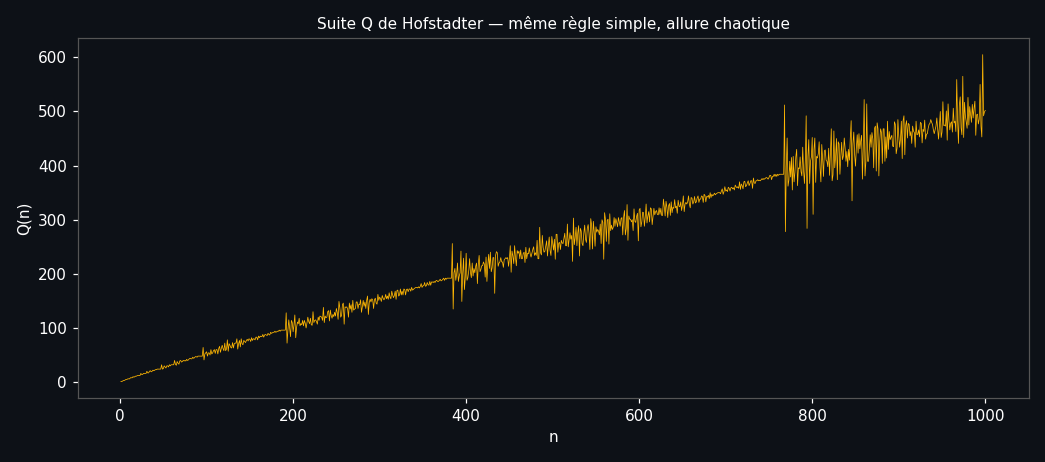

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# La suite Q de Hofstadter, autrement plus sauvage : Q(1)=Q(2)=1, et pour n>2,
# Q(n) = Q(n - Q(n-1)) + Q(n - Q(n-2)). Contrairement à G, elle est chaotique :
# personne ne sait si elle est bien définie pour tout n (elle pourrait un jour
# demander un indice négatif ou nul), et son allure ressemble à un bruit erratique
# malgré une règle de construction parfaitement déterministe.
def hofstadter_Q(n_max):
    Q = [None, 1, 1]  # index 0 inutilisé, Q[1]=Q[2]=1
    for n in range(3, n_max+1):
        Q.append(Q[n - Q[n-1]] + Q[n - Q[n-2]])
    return Q[1:]

N = 1000
Q = hofstadter_Q(N)
print("Premiers termes de Q :", Q[:20])
print(f"La suite reste bien définie jusqu'à n={N} sans jamais réclamer d'indice <= 0.")

fig, ax = plt.subplots(figsize=(9.5, 4.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.plot(range(1, N+1), Q, color="#ffb703", lw=0.5)
ax.set_xlabel("n", color="white")
ax.set_ylabel("Q(n)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Suite Q de Hofstadter — même règle simple, allure chaotique", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out2.png", dpi=110, facecolor=fig.get_facecolor())


## 3. Le système MIU et le puzzle MU <a id="3"></a>

Le tout premier chapitre de GEB pose une énigme désarmante de simplicité : à partir de la chaîne "MI" et
de quatre règles de réécriture mécaniques, peut-on un jour obtenir "MU" ? Hofstadter s'en sert pour faire
sentir, avant même de prononcer le nom de Gödel, la différence entre ce qui est *vrai à propos* d'un
système formel et ce qui est *démontrable à l'intérieur* de ce système : ici, un simple argument
d'invariant (le nombre de I modulo 3) suffit à prouver, de l'extérieur, que MU est à jamais hors
d'atteinte — sans avoir à explorer l'infinité des chaînes engendrables.

46 chaînes explorées (profondeur <= 5, longueur <= 10)
Valeurs de (nombre de I) mod 3 observées parmi ces chaînes : [1, 2]
'MU' possède 0 I, donc 0 mod 3 -- une valeur qui n'apparaît jamais : MU est inatteignable.
'MU' a-t-il été engendré ? False


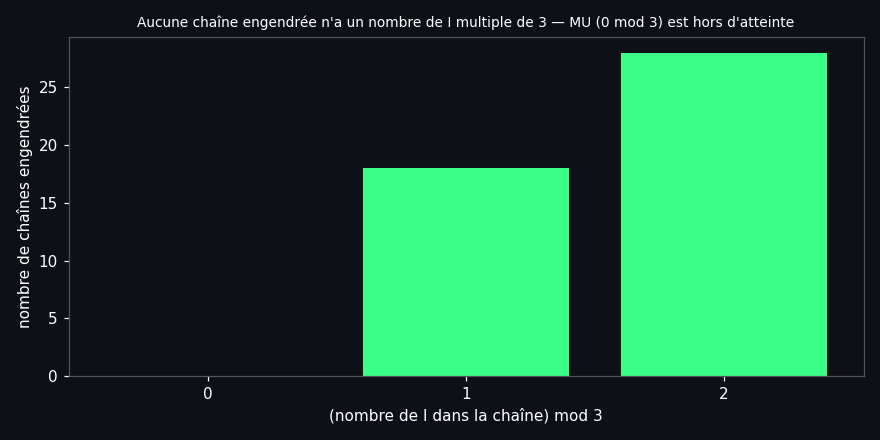

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from collections import deque

# Le système MIU ouvre GEB : un jeu formel sur les lettres M, I, U avec 4 règles
# de réécriture. Partant de "MI", peut-on obtenir "MU" ?
#   1) xI      -> xIU
#   2) Mx      -> Mxx
#   3) xIIIy   -> xUy   (remplace III par U)
#   4) xUUy    -> xy    (supprime UU)
# Hofstadter s'en sert pour faire toucher du doigt, avant même de parler de
# Gödel, la différence entre "vrai" et "démontrable à l'intérieur du système" :
# on peut prouver que MU est hors de portée grâce à un invariant.

def apply_rules(s):
    results = set()
    if s.endswith("I"):
        results.add(s + "U")                       # règle 1
    if s.startswith("M"):
        results.add("M" + s[1:] + s[1:])            # règle 2
    for i in range(len(s)-2):
        if s[i:i+3] == "III":
            results.add(s[:i] + "U" + s[i+3:])       # règle 3
    for i in range(len(s)-1):
        if s[i:i+2] == "UU":
            results.add(s[:i] + s[i+2:])             # règle 4
    return results

start = "MI"
visited = {start}
queue = deque([(start, 0)])
max_len = 10
depth_reached = 0
while queue:
    s, d = queue.popleft()
    if d >= 5 or len(s) > max_len:
        continue
    for nxt in apply_rules(s):
        if nxt not in visited:
            visited.add(nxt)
            queue.append((nxt, d+1))
            depth_reached = max(depth_reached, d+1)

i_counts = sorted(set(s.count("I") % 3 for s in visited))
print(f"{len(visited)} chaînes explorées (profondeur <= 5, longueur <= {max_len})")
print(f"Valeurs de (nombre de I) mod 3 observées parmi ces chaînes : {i_counts}")
print(f"'MU' possède 0 I, donc 0 mod 3 -- une valeur qui n'apparaît jamais : MU est inatteignable.")
print(f"'MU' a-t-il été engendré ? {'MU' in visited}")

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
counts = {0: 0, 1: 0, 2: 0}
for s in visited:
    counts[s.count("I") % 3] += 1
colors = ["#ff5da2" if k == 0 else "#39ff88" for k in counts]
ax.bar([str(k) for k in counts], list(counts.values()), color=colors)
ax.set_xlabel("(nombre de I dans la chaîne) mod 3", color="white")
ax.set_ylabel("nombre de chaînes engendrées", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Aucune chaîne engendrée n'a un nombre de I multiple de 3 — MU (0 mod 3) est hors d'atteinte", color="white", fontsize=9)
plt.tight_layout()
plt.savefig("out3.png", dpi=110, facecolor=fig.get_facecolor())


## 4. Le cube de Necker <a id="4"></a>

GEB revient constamment sur les figures ambiguës et impossibles d'Escher (les escaliers de *Montée et
descente*, la chute d'eau de *Cascade*) pour interroger la façon dont l'esprit "bascule" entre deux
lectures d'une même image. Le cube de Necker, plus ancien (1832) et plus dépouillé, en est l'épure
parfaite : un simple dessin filaire, sans la moindre information de profondeur réelle, que le cerveau
force pourtant à se voir en trois dimensions — selon l'une ou l'autre de deux orientations parfaitement
incompatibles.

Le dessin du milieu ne fournit aucune information de profondeur : c'est le cerveau qui
impose l'une des deux interprétations, et peut basculer spontanément de l'une à l'autre.


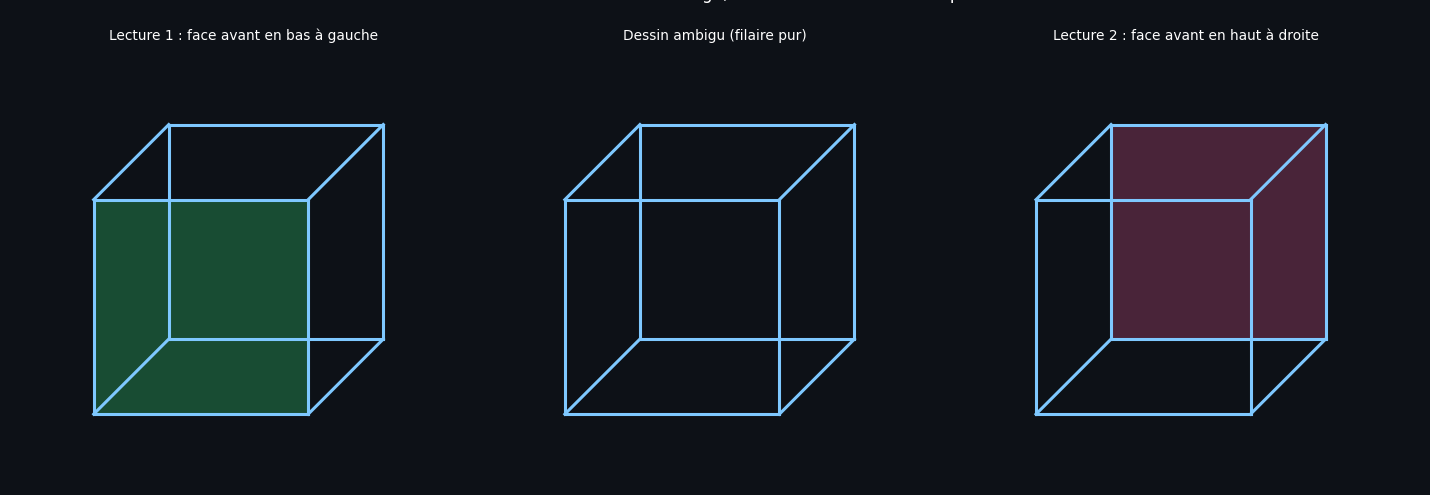

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# GEB revient sans cesse sur les images ambiguës et impossibles (Escher en
# particulier) pour interroger la façon dont l'esprit "bascule" entre deux
# lectures d'une même figure. Le cube de Necker en est l'exemple le plus pur :
# le même dessin filaire se laisse voir de deux façons opposées, et le cerveau
# ne peut en tenir qu'une seule à la fois.

def cube_edges(offset=(0.35, 0.35)):
    front = [(0,0),(1,0),(1,1),(0,1)]
    back = [(x+offset[0], y+offset[1]) for x,y in front]
    return front, back

front, back = cube_edges()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor="#0d1117")
titles = ["Lecture 1 : face avant en bas à gauche", "Dessin ambigu (filaire pur)", "Lecture 2 : face avant en haut à droite"]

for ax, title, mode in zip(axes, titles, ["a","n","b"]):
    ax.set_facecolor("#0d1117")
    for i in range(4):
        x1,y1 = front[i]; x2,y2 = front[(i+1)%4]
        ax.plot([x1,x2],[y1,y2], color="#7ec8ff", lw=2)
    for i in range(4):
        x1,y1 = back[i]; x2,y2 = back[(i+1)%4]
        ax.plot([x1,x2],[y1,y2], color="#7ec8ff", lw=2)
    for i in range(4):
        x1,y1 = front[i]; x2,y2 = back[i]
        ax.plot([x1,x2],[y1,y2], color="#7ec8ff", lw=2)
    if mode == "a":
        fx, fy = zip(*front)
        ax.fill(fx, fy, color="#39ff88", alpha=0.25)
    elif mode == "b":
        bx, by = zip(*back)
        ax.fill(bx, by, color="#ff5da2", alpha=0.25)
    ax.set_xlim(-0.3, 1.7); ax.set_ylim(-0.3, 1.7)
    ax.set_aspect("equal"); ax.set_axis_off()
    ax.set_title(title, color="white", fontsize=9)

fig.suptitle("Le cube de Necker : une seule image, deux structures 3D incompatibles", color="white", fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig("out4.png", dpi=110, facecolor=fig.get_facecolor())
print("Le dessin du milieu ne fournit aucune information de profondeur : c'est le cerveau qui")
print("impose l'une des deux interprétations, et peut basculer spontanément de l'une à l'autre.")


## 5. Le dilemme du prisonnier et la super-rationalité <a id="5"></a>

Dans sa chronique "Metamagical Themas" du *Scientific American*, Hofstadter propose une idée qui a fait
couler beaucoup d'encre chez les théoriciens de la décision : la **super-rationalité**. Face à un dilemme
du prisonnier en un seul coup, sans communication, contre un adversaire dont on sait qu'il raisonne
exactement comme soi, un agent super-rationnel comprend que, par pure symétrie, les deux joueurs
choisiront forcément la même case du tableau des gains — la question se réduit alors à comparer
"coopération mutuelle" et "trahison mutuelle", et non plus à chercher une stratégie dominante comme le
voudrait la théorie des jeux classique.

Raisonnement classique (théorie des jeux orthodoxe) :
  Trahir domine coopérer quel que soit le choix de l'autre -> les deux trahissent -> (1,1)

Raisonnement super-rationnel (Hofstadter) :
  'Je raisonne comme mon adversaire, donc nous choisirons la même case du tableau.'
  Il ne reste que deux issues symétriques possibles à comparer :
    ('C', 'C') -> gains (3, 3)
    ('D', 'D') -> gains (1, 1)
  (3,3) > (1,1) pour les deux joueurs -> un agent super-rationnel choisit de COOPÉRER,
  sans le moindre accord préalable ni communication.


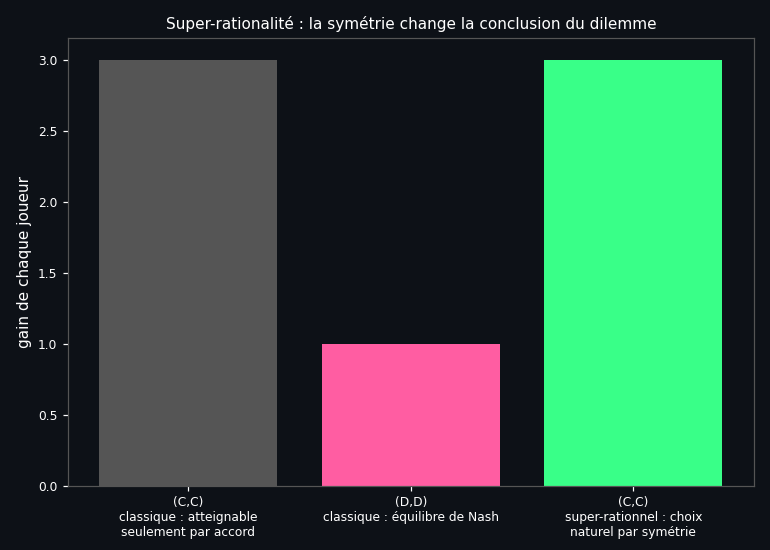

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Dans sa chronique "Metamagical Themas" (Scientific American), Hofstadter propose
# la "super-rationalité" : face à un dilemme du prisonnier en UN SEUL coup contre
# un adversaire dont on sait qu'il raisonne exactement comme soi, un joueur
# super-rationnel réalise que, par symétrie, les deux joueurs choisiront forcément
# la MÊME action. La question se réduit alors à : "coopération mutuelle ou
# trahison mutuelle valent-elles mieux ?" -- et non plus au calcul habituel
# (dominant strategy) qui suppose implicitement des choix indépendants.

PAYOFF = {("C","C"): (3,3), ("C","D"): (0,5), ("D","C"): (5,0), ("D","D"): (1,1)}

print("Raisonnement classique (théorie des jeux orthodoxe) :")
print("  Trahir domine coopérer quel que soit le choix de l'autre -> les deux trahissent -> (1,1)")
print()
print("Raisonnement super-rationnel (Hofstadter) :")
print("  'Je raisonne comme mon adversaire, donc nous choisirons la même case du tableau.'")
print("  Il ne reste que deux issues symétriques possibles à comparer :")
for outcome in [("C","C"), ("D","D")]:
    print(f"    {outcome} -> gains {PAYOFF[outcome]}")
print("  (3,3) > (1,1) pour les deux joueurs -> un agent super-rationnel choisit de COOPÉRER,")
print("  sans le moindre accord préalable ni communication.")

fig, ax = plt.subplots(figsize=(7, 5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
labels = ["(C,C)\nclassique : atteignable\nseulement par accord", "(D,D)\nclassique : équilibre de Nash",
          "(C,C)\nsuper-rationnel : choix\nnaturel par symétrie"]
values = [3, 1, 3]
colors = ["#555", "#ff5da2", "#39ff88"]
ax.bar(labels, values, color=colors)
ax.set_ylabel("gain de chaque joueur", color="white")
ax.tick_params(colors="white", labelsize=8)
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Super-rationalité : la symétrie change la conclusion du dilemme", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out5.png", dpi=110, facecolor=fig.get_facecolor())


## 6. Les canons crabes <a id="6"></a>

Le "Canon crabe" (*Crab Canon*) de Bach, extrait de l'*Offrande musicale*, est joué par deux voix : la
seconde interprète exactement la mélodie de la première, mais lue à l'envers dans le temps — comme un
crabe qui marche de travers. Hofstadter en fait l'un des trois piliers structurels de GEB, jusqu'à écrire
lui-même un dialogue en canon crabe dont la seconde moitié répète la première mot pour mot, mais à
rebours. Ci-dessous, une mélodie jouet et son reflet temporel exact.

Mélodie      : [0, 2, 4, 5, 7, 5, 4, 2, 4, 7, 9, 7]
Rétrograde   : [7, 9, 7, 4, 2, 4, 5, 7, 5, 4, 2, 0]
La voix 2 lue de droite à gauche redonne exactement la voix 1 -- symétrie miroir parfaite.


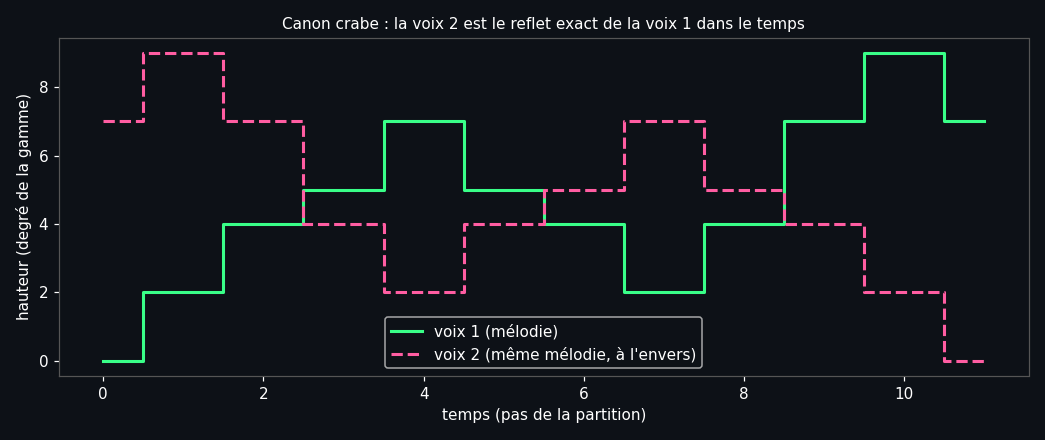

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Le "Canon crabe" (Crab Canon) de Bach, dans l'Offrande musicale, est joué par
# deux voix : la seconde interprète EXACTEMENT la même mélodie que la première,
# mais à l'envers dans le temps -- comme un crabe qui marche de travers. GEB en
# fait un des trois piliers du livre (avec les dialogues en canon crabe de
# Hofstadter lui-même, où la seconde moitié du dialogue répète la première à
# rebours). Ici, une mélodie jouet et son reflet temporel exact.

melody = [0, 2, 4, 5, 7, 5, 4, 2, 4, 7, 9, 7]  # degrés d'une gamme, à titre d'exemple
retrograde = melody[::-1]

fig, ax = plt.subplots(figsize=(9.5, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
t = list(range(len(melody)))
ax.step(t, melody, where="mid", color="#39ff88", lw=2, label="voix 1 (mélodie)")
ax.step(t, retrograde, where="mid", color="#ff5da2", lw=2, ls="--", label="voix 2 (même mélodie, à l'envers)")
ax.set_xlabel("temps (pas de la partition)", color="white")
ax.set_ylabel("hauteur (degré de la gamme)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.legend(facecolor="#0d1117", labelcolor="white")
ax.set_title("Canon crabe : la voix 2 est le reflet exact de la voix 1 dans le temps", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out6.png", dpi=110, facecolor=fig.get_facecolor())
print("Mélodie      :", melody)
print("Rétrograde   :", retrograde)
print("La voix 2 lue de droite à gauche redonne exactement la voix 1 -- symétrie miroir parfaite.")


## 7. Boucles étranges : le quine <a id="7"></a>

*I Am a Strange Loop* (2007) place au cœur de la conscience, selon Hofstadter, une "boucle étrange" : un
système qui, en remontant à travers ses propres niveaux de description, finit par se désigner lui-même
dans sa totalité — un peu comme l'escalier de Penrose qui, marche après marche, revient à son point de
départ. Le **quine**, un programme qui affiche exactement son propre code source sans jamais lire le
fichier qui le contient, en est la version la plus littérale et la plus vérifiable qui soit.

In [7]:
# "I Am a Strange Loop" (2007) place au coeur de la conscience selon Hofstadter
# une "boucle étrange" : un système qui, en se repliant sur lui-même à travers
# plusieurs niveaux, finit par se référer à sa propre totalité. Le "quine" --
# un programme qui affiche exactement son propre code source, sans jamais lire
# le fichier qui le contient -- en est l'incarnation la plus littérale possible.

quine = 's = %r\nprint(s %% s)'
programme_source = quine % quine

print("--- Code source du programme ---")
print(programme_source)
print("--- Ce que ce programme affiche quand on l'exécute ---")

import io, contextlib
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    exec(programme_source)
sortie = buf.getvalue()
print(sortie, end="")

print("--- Vérification ---")
print(f"La sortie est-elle identique au code source, caractère pour caractère ? {sortie.rstrip(chr(10)) == programme_source}")
print()
print("Ce petit programme s'imprime lui-même : pas d'astuce de lecture de fichier, juste")
print("une chaîne qui se décrit elle-même — la boucle étrange sous sa forme la plus nue.")


--- Code source du programme ---
s = 's = %r\nprint(s %% s)'
print(s % s)
--- Ce que ce programme affiche quand on l'exécute ---
s = 's = %r\nprint(s %% s)'
print(s % s)
--- Vérification ---
La sortie est-elle identique au code source, caractère pour caractère ? True

Ce petit programme s'imprime lui-même : pas d'astuce de lecture de fichier, juste
une chaîne qui se décrit elle-même — la boucle étrange sous sa forme la plus nue.


## 8. Copycat : le raisonnement par analogie <a id="8"></a>

Hofstadter a consacré une grande partie de sa carrière de chercheur (avec Melanie Mitchell) au projet
**Copycat** : un programme censé résoudre des analogies de lettres comme "abc se transforme en abd ; que
devient ijk ?" — non pas par une règle rigide, mais en laissant émerger la réponse la plus "naturelle"
parmi plusieurs candidates possibles, via ce qu'il appelle le **glissement conceptuel**. Le cas piège
classique : "xyz -> ?", où appliquer la règle à la lettre donne une réponse techniquement correcte mais
peu satisfaisante, tandis qu'une analogie de *rôle* plutôt que de *position littérale* semble bien plus
convaincante à l'intuition humaine.

Règle apprise sur 'abc -> abd' : incrémenter la dernière lettre.

  ijk -> ijl
  abd -> abe
  xyz -> xya

Le cas 'xyz' est le piège classique de Copycat : incrémenter 'z' redonne 'a' (a %% 26),
ce qui donne 'xya' -- une réponse techniquement correcte mais insatisfaisante. La plupart
des humains (et Copycat, le plus souvent) préfèrent un « glissement conceptuel » :
puisque 'z' est la DERNIÈRE lettre de l'alphabet comme 'c' était la dernière de 'abc',
on décale plutôt tout le mot d'un cran : 'xyz' -> 'wyz' (percevoir 'z' comme jouant
le rôle-limite de 'c', par analogie de rôle plutôt que de position littérale).


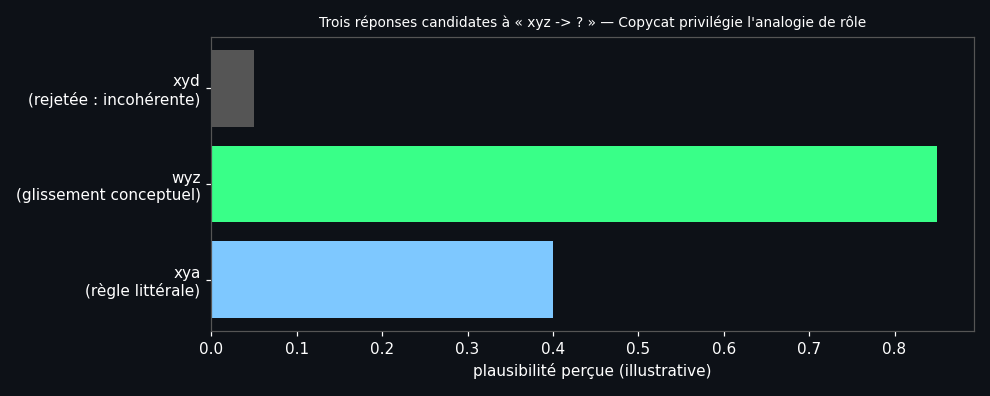

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import string

# Hofstadter a consacré une grande partie de sa carrière (avec Melanie Mitchell)
# au projet Copycat : un programme qui résout des analogies de lettres comme
# "abc se transforme en abd ; que devient ijk ?" -- non pas par une règle rigide,
# mais en laissant émerger la réponse la plus "naturelle" parmi plusieurs
# possibles, via ce qu'il appelle le "glissement conceptuel" (conceptual slippage).

def successor(letter):
    idx = string.ascii_lowercase.index(letter)
    return string.ascii_lowercase[(idx + 1) % 26]

def apply_increment_last(s):
    return s[:-1] + successor(s[-1])

examples = ["ijk", "abd", "xyz"]
print("Règle apprise sur 'abc -> abd' : incrémenter la dernière lettre.\n")
for s in examples:
    result = apply_increment_last(s)
    print(f"  {s} -> {result}")

print()
print("Le cas 'xyz' est le piège classique de Copycat : incrémenter 'z' redonne 'a' (a %% 26),")
print("ce qui donne 'xya' -- une réponse techniquement correcte mais insatisfaisante. La plupart")
print("des humains (et Copycat, le plus souvent) préfèrent un « glissement conceptuel » :")
print("puisque 'z' est la DERNIÈRE lettre de l'alphabet comme 'c' était la dernière de 'abc',")
print("on décale plutôt tout le mot d'un cran : 'xyz' -> 'wyz' (percevoir 'z' comme jouant")
print("le rôle-limite de 'c', par analogie de rôle plutôt que de position littérale).")

fig, ax = plt.subplots(figsize=(9, 3.6), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
candidates = ["xya\n(règle littérale)", "wyz\n(glissement conceptuel)", "xyd\n(rejetée : incohérente)"]
scores = [0.4, 0.85, 0.05]
colors = ["#7ec8ff", "#39ff88", "#555"]
ax.barh(candidates, scores, color=colors)
ax.set_xlabel("plausibilité perçue (illustrative)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Trois réponses candidates à « xyz -> ? » — Copycat privilégie l'analogie de rôle", color="white", fontsize=9)
plt.tight_layout()
plt.savefig("out8.png", dpi=110, facecolor=fig.get_facecolor())


## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : un slider `ipywidgets` pour explorer la suite Q de Hofstadter sur une plage de termes
ajustable, et un second pour tester sa propre règle d'analogie sur un mot de trois lettres au choix.
Idéal pour montrer qu'un notebook Jupyter est un vrai labo interactif, pas juste un exécuteur de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, IntSlider, Text
import matplotlib.pyplot as plt
import string

def hofstadter_Q(n_max):
    Q = [None, 1, 1]
    for n in range(3, n_max+1):
        Q.append(Q[n - Q[n-1]] + Q[n - Q[n-2]])
    return Q[1:]

def show_Q(n_max=200):
    Q = hofstadter_Q(max(n_max, 3))
    fig, ax = plt.subplots(figsize=(8, 3.5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.plot(range(1, len(Q)+1), Q, color="#ffb703", lw=0.6)
    ax.tick_params(colors="white")
    ax.set_title(f"Suite Q de Hofstadter jusqu'à n={n_max}", color="white")
    plt.show()

def successor(letter):
    idx = string.ascii_lowercase.index(letter)
    return string.ascii_lowercase[(idx + 1) % 26]

def try_analogy(word="ijk"):
    word = word.lower().strip()
    if len(word) != 3 or not word.isalpha():
        print("Entre un mot de 3 lettres, par exemple 'ijk'.")
        return
    literal = word[:-1] + successor(word[-1])
    print(f"{word} -> {literal}  (règle littérale : incrémenter la dernière lettre)")

interact(show_Q, n_max=IntSlider(200, min=10, max=2000, step=10))
interact(try_analogy, word=Text(value="ijk"))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Douglas Hofstadter**, *Gödel, Escher, Bach: an Eternal Golden Braid* (1979) — Prix Pulitzer, la bible de l'auto-référence
- **Douglas Hofstadter**, *Metamagical Themas* (1985) — chroniques Scientific American, super-rationalité
- **Douglas Hofstadter**, *I Am a Strange Loop* (2007) — boucles étranges et conscience
- **Douglas Hofstadter & Melanie Mitchell**, articles sur le projet **Copycat** — analogie et glissement conceptuel
- **Douglas Hofstadter**, *Le Ton beau de Marot* (1997) — traduction, contrainte, auto-référence

---
*Notebook généré pour une démo JupyterLab, en écho aux notebooks Gardner, Pickover, Stewart, Delahaye,
du Sautoy et Rucker — libre à toi de piocher, couper, ou dupliquer les cellules selon le public visé.*
